# Eigensystem Solutions

In [23]:
%load_ext autoreload
%autoreload 2

import numpy as np
    
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import inspect

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
from pyabs.core.basis import ABSBasisConfig, build_abs_basis
from pyabs.core.matrix import build_abs_matrix
from pyabs.core.wake import ThetaWake, WakeScale
from pyabs.solvers.eigensolvers import solve_eigenvalues, solve_eigensystem, solve_system

In [25]:
n_max=5
basis = build_abs_basis(np, ABSBasisConfig(n_max=n_max, q=0))

In [26]:
theta_wake = ThetaWake(W0=1)

In [27]:
matrix = build_abs_matrix(basis, wake_model=theta_wake, scale=WakeScale(w = 1))

In [28]:
#eigenvalue_i, eigenvectors_i 
eigensolution = solve_eigensystem(matrix)
eigenvalues = np.array(eigensolution.eigenvalues)
eigenvectors= np.array(eigensolution.eigenvectors)

In [29]:
solution = solve_system(matrix, A0=1)

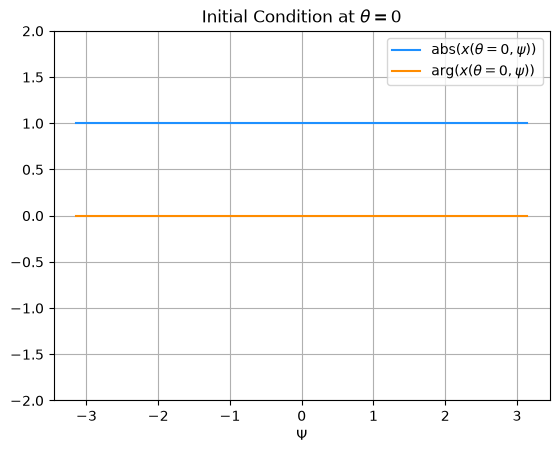

In [30]:
psi_range = np.linspace(-np.pi, np.pi, 100)
yabs = []
yarg = []
for psi in psi_range:
    soln = solution.compute_x(theta=0, psi=psi)
    yabs.append(np.abs(soln))
    yarg.append(np.angle(soln))

fig, ax = plt.subplots()
ax.set_ylim(-2,2)
plt.title(r"Initial Condition at $\theta = 0$")
plt.grid()
plt.plot(psi_range, yabs, color='dodgerblue', label = r"abs($x$($\theta=0, \psi$))")
plt.plot(psi_range, yarg, color='darkorange', label = r"arg($x$($\theta=0, \psi$))")
#ax.set_ylabel(r"$\nu_{k}$")
plt.legend()
ax.set_xlabel(r"$\Psi$")
plt.savefig("../../plots/initial_condition_confirmation.png", dpi=300)
plt.show()

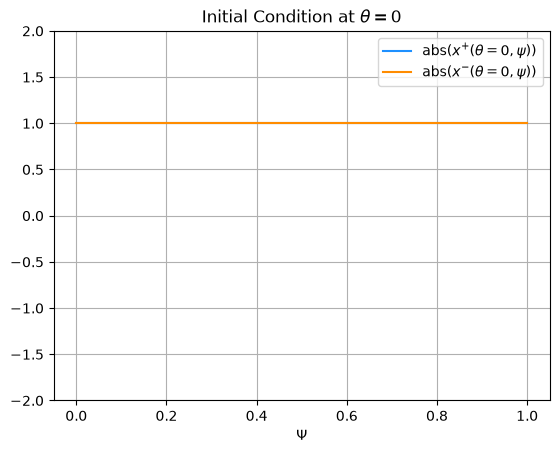

In [44]:
s_range = np.linspace(0, 1, 100)
plusabs = []
minusabs = []
for s in s_range:
    plus = solution.compute_xplus(theta=0, s=s)
    minus= solution.compute_xminus(theta=0, s=s)
    plusabs.append(np.abs(plus))
    minusabs.append(np.abs(minus))

fig, ax = plt.subplots()
ax.set_ylim(-2,2)
plt.title(r"Initial Condition at $\theta = 0$")
plt.grid()
plt.plot(s_range, plusabs, color='dodgerblue', label = r"abs($x^{\plus}$($\theta=0, \psi$))")
plt.plot(s_range, minusabs, color='darkorange', label = r"abs($x^{\minus}$($\theta=0, \psi$))")
#ax.set_ylabel(r"$\nu_{k}$")
plt.legend()
ax.set_xlabel(r"$\Psi$")
plt.savefig("../../plots/initialcond_sversion.png", dpi=300)
plt.show()

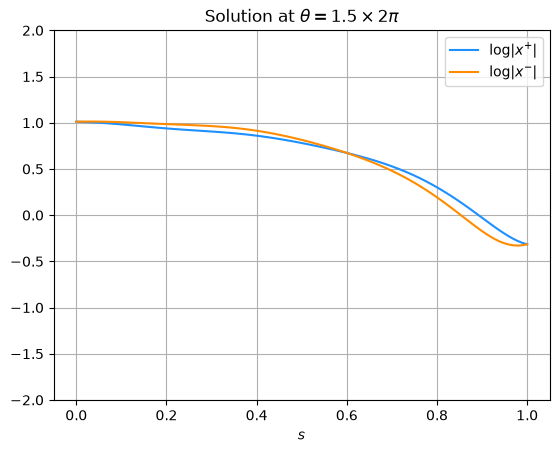

In [52]:
s_range = np.linspace(0, 1, 100)
logplusabs = []
logminusabs = []
for s in s_range:
    plus = solution.compute_xplus(theta=1.5*2*np.pi, s=s)
    minus= solution.compute_xminus(theta=1.5*2*np.pi, s=s)
    logplusabs.append(np.log(np.abs(plus)))
    logminusabs.append(np.log(np.abs(minus)))
    
fig, ax = plt.subplots()
ax.set_ylim(-2,2)
plt.title(r"Solution at $\theta = 1.5\times2\pi$")
plt.grid()
plt.plot(s_range, logplusabs, color='dodgerblue', label = r"log|$x^{\plus}$|")
plt.plot(s_range, logminusabs, color='darkorange', label = r"log|$x^{\minus}$|")
#ax.set_ylabel(r"$\nu_{k}$")
plt.legend()
ax.set_xlabel(r"$s$")
plt.savefig("../../plots/latersolution.png", dpi=300)
plt.show()

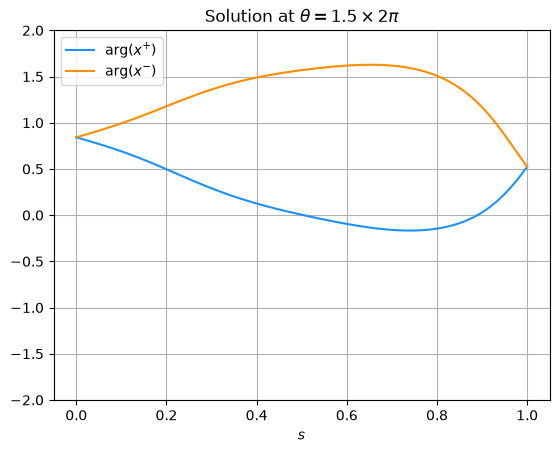

In [50]:
s_range = np.linspace(0, 1, 100)
logplusabs = []
logminusabs = []
for s in s_range:
    plus = solution.compute_xplus(theta=1.5*2*np.pi, s=s)
    minus= solution.compute_xminus(theta=1.5*2*np.pi, s=s)
    logplusabs.append(np.angle(plus))
    logminusabs.append(np.angle(minus))
    
fig, ax = plt.subplots()
ax.set_ylim(-2,2)
plt.title(r"Solution at $\theta = 1.5\times2\pi$")
plt.grid()
plt.plot(s_range, logplusabs, color='dodgerblue', label = r"arg($x^{\plus}$)")
plt.plot(s_range, logminusabs, color='darkorange', label = r"arg($x^{\minus}$)")
#ax.set_ylabel(r"$\nu_{k}$")
plt.legend()
ax.set_xlabel(r"$s$")
plt.savefig("../../plots/latersolution_arg.png", dpi=300)
plt.show()